In [1]:
import logging
from pathlib import Path
import pandas as pd
# from utils import compute_roll_sum
# from ngcm import process_ngcm
# from aifs import process_aifs
import numpy as np


In [2]:
def compute_roll_sum(arr: np.ndarray, n: int) -> np.ndarray:
    """
    Left-aligned rolling sum; positions without full window return NaN.
    """
    s = pd.Series(arr)
    rolled = s.rolling(n, min_periods=n).sum()
    #align left instead of right
    rolled = rolled.shift(-(n-1))
    return rolled.to_numpy()

def compute_quasi_onset(series: np.ndarray, window: int, thresh: float) -> np.ndarray:
    """
    Boolean array: True where series>1 and rolling sum>thresh.
    """
    n = series.size
    if n < window:
        return np.zeros(n, dtype=bool)
    roll_sum = pd.Series(series).rolling(window, min_periods=window).sum().to_numpy()
    valid = (series > 1) & (roll_sum > thresh)
    return np.nan_to_num(valid, False).astype(bool)

def find_onset(series: np.ndarray, window: int, thresh: float) -> float:
    """
    Return 1-based index of first day where series>1 and rolling sum>thresh, else NaN.
    """
    if series.size < window:
        return np.nan
    roll_sum = pd.Series(series).rolling(window, min_periods=window).sum().to_numpy()
    cond = (series > 1) & (roll_sum > thresh)
    idx = np.where(cond)[0]
    return float(idx[0] + 1) if idx.size > 0 else np.nan

In [3]:
# logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s:%(message)s')

base = Path("/scratch/midway3/marchakitus/monsoon-onset/blend/utils")
    
#copies of each of these files are in the py folder I sent Adam
thresholds_file = base / "thresholds_df.csv"
clusters_file = base / "onset_clusters.csv"
mat_file = base / "onset_five_day_thres_2deg.mat"
clim_file = base / "ensemble_outputs_clim_2025.csv"
allowed_cells_file = base / "allowed_cells.csv"
aifs_tp_file = Path("/scratch/midway3/marchakitus/AIFS/2022_selected_2.nc")
ngcm_precip_file = Path("/scratch/midway3/marchakitus/neuralgcm/2022_selected_2.nc")
out = base / 'intermediate' / 'input_to_blend.csv' #output location

allowed_cells = pd.read_csv(allowed_cells_file)

In [4]:
# AI-Generated: PLEASE CHECK BEFORE DEPLOYMENT

import logging
from pathlib import Path
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from scipy.io import loadmat
from multiprocessing import Pool
from functools import partial
# from utils import find_onset, compute_quasi_onset

def _ngcm_worker(coord,
                  mat_lat: np.ndarray,
                  mat_lon: np.ndarray,
                  onset_thresh: np.ndarray,
                  pc: np.ndarray,
                  fdates: np.ndarray,
                  valid_days: np.ndarray,
                  dayv: np.ndarray,
                  window: int,
                  max_day: int,
                  wa: np.ndarray,
                  tw: np.ndarray) -> pd.DataFrame:
    li, lj = coord
    latv = mat_lat[li]
    lonv = mat_lon[lj]
    thr = onset_thresh[li, lj]
    recs = []
    # print(pc.shape, valid_days.shape, fdates.shape, dayv.shape, li, lj)
    for ti, fdate in enumerate(fdates):
        raw = np.transpose(pc, (1, 0, 2, 3, 4))  # [days, ens, lat, lon]
        raw = raw[valid_days, ti, :, li, lj]  # [days, ens]
        arr = raw.T                       # [ens, days]
        ens_mean = np.nanmean(arr, axis=0)
        ens_sd = np.nanstd(arr, axis=0)

        for di, d in enumerate(dayv):
            if d > max_day:
                break
            onset_idx = [find_onset(arr[m, :], window, thr) for m in range(arr.shape[0])]
            prob = np.mean([(o == d) for o in onset_idx if not np.isnan(o)])
            qmat = np.vstack([compute_quasi_onset(arr[m, :], window, thr)
                               for m in range(arr.shape[0])])
            qprob = np.mean(qmat[:, di])

            vw = vw_sd = vt = vt_sd = None
            if wa is not None:
                vw = np.nanmean(wa[:, ti, di]); vw_sd = np.nanstd(wa[:, ti, di])
            if tw is not None:
                vt = np.nanmean(tw[lj, li, :, ti, di]); vt_sd = np.nanstd(tw[lj, li, :, ti, di])

            recs.append({
                'time': fdate,
                'day': d,
                'onset_thresh': thr,
                'predicted_prob': prob,
                'predicted_quasi_prob': qprob,
                'ngcm_rain_daily': ens_mean[di],
                'ngcm_rain_daily_sd': ens_sd[di],
                'v_wind': vw,
                'v_wind_sd': vw_sd,
                'v_tcw': vt,
                'v_tcw_sd': vt_sd,
                'lat': latv,
                'lon': lonv
            })
    return pd.DataFrame(recs)

def process_ngcm(precip_file: Path,
                 mat_file: Path,
                 allowed_cells: pd.DataFrame,
                 window: int = 5,
                 max_day: int = 40,
                 min_day: int = 1,
                 cutoff_month_day: str = "04-01") -> pd.DataFrame:
    logging.info("Processing NGCM without IMD masking")

    # Load MAT thresholds
    mat = loadmat(str(mat_file))
    mat_lat = mat['lat'].flatten()
    mat_lon = mat['lon'].flatten()
    onset_thresh = mat.get('onset_day_thres', mat.get('onset.thres'))

    # Read NGCM precipitation
    if not precip_file.exists():
        logging.warning(f"NGCM precip missing: {precip_file}")
        return pd.DataFrame()
    with Dataset(precip_file) as nc:
        pc       = nc.variables['tp'][:]
        tvals2   = nc.variables['time'][:]
        day_vals = nc.variables['day'][:]
        tu       = nc.variables['time'].units

    origin2 = pd.to_datetime(tu.split(' since ')[1])
    fdates  = origin2 + pd.to_timedelta(tvals2, unit='D')

    year    = fdates[0].year
    start_date = pd.to_datetime(f"{year}-{cutoff_month_day}")
    valid_f = np.where(fdates >= start_date)[0]

    if valid_f.size == 0:
        logging.warning(f"No NGCM forecast >= {start_date.date()}")
        return pd.DataFrame()
    # print(valid_f)
    # print(pc.shape)
    pc     = pc[:, :, valid_f, :, :]
    # print(pc.shape)
    fdates = fdates[valid_f]

    valid_days = np.where((day_vals >= min_day) & (day_vals <= max_day + window - 1))[0]
    dayv       = day_vals[valid_days]

    # Identify coordinates directly from allowed_cells
    coords = []
    for _, row in allowed_cells.iterrows():
        latv = row['lat']; lonv = row['lon']
        li = np.where(mat_lat == latv)[0]
        lj = np.where(mat_lon == lonv)[0]
        if li.size and lj.size:
            coords.append((li[0], lj[0]))

    if not coords:
        logging.warning("No valid coordinates based on allowed_cells")
        return pd.DataFrame()

    # Read SJI (wind) - placeholder
    wa = None
    # placeholder for tcw
    tw = None

    # Prepare worker
    worker = partial(_ngcm_worker,
                     mat_lat=mat_lat,
                     mat_lon=mat_lon,
                     onset_thresh=onset_thresh,
                     pc=pc,
                     fdates=fdates,
                     valid_days=valid_days,
                     dayv=dayv,
                     window=window,
                     max_day=max_day,
                     wa=wa,
                     tw=tw)

    with Pool() as pool:
        dfs = pool.map(worker, coords)

    return pd.concat([df for df in dfs if not df.empty], ignore_index=True)


In [6]:
# AI-Generated: PLEASE CHECK BEFORE DEPLOYMENT
import logging
from pathlib import Path
import numpy as np
import pandas as pd
from netCDF4 import Dataset
from scipy.io import loadmat
# from utils import find_onset, compute_quasi_onset

def process_aifs(tp_file: Path,
                 mat_file: Path,
                 allowed_cells: pd.DataFrame,
                 window: int = 5,
                 max_day: int = 40,
                 min_day: int = 1) -> pd.DataFrame:
    logging.info("Processing AIFS")

    # Load thresholds
    mat = loadmat(str(mat_file))
    mat_lat = mat['lat'].flatten()
    mat_lon = mat['lon'].flatten()
    onset_thresh = mat.get('onset_day_thres', mat.get('onset.thres'))

    # Read AIFS TP file
    if not tp_file.exists():
        logging.warning(f"AIFS TP missing: {tp_file}")
        return pd.DataFrame()
    with Dataset(tp_file) as nc:
        tp_data = nc.variables['tp'][:]       # [day, time, lat, lon]
        tvals   = nc.variables['time'][:]
        dvals   = nc.variables['day'][:]
        time_units = nc.variables['time'].units
        print(nc)

    tp = np.transpose(tp_data, (3, 2, 1, 0))  # (nlon, nlat, ntime, nday)

    # Build forecast dates
    origin = pd.to_datetime(time_units.split(' since ')[1])
    fdates = origin + pd.to_timedelta(tvals, unit='D')

    # Filter days by min/max + window
    valid_days = np.where((dvals >= min_day) & (dvals <= max_day + window - 1))[0]

    # Identify coordinates directly from allowed_cells
    coords = []
    for _, row in allowed_cells.iterrows():
        latv = row['lat']; lonv = row['lon']
        li = np.where(mat_lat == latv)[0]
        lj = np.where(mat_lon == lonv)[0]
        if li.size and lj.size:
            coords.append((li[0], lj[0]))

    if not coords:
        logging.warning("No valid coordinates based on allowed_cells")
        return pd.DataFrame()

    # Placeholder for wind/TCW
    sji = None
    tcw = None

    # Loop over coords and forecasts
    records = []
    for (li, lj) in coords:
        thr = onset_thresh[li, lj]
        for ti, fdate in enumerate(fdates):
            series = tp[lj, li, ti, valid_days]
            for idx, day_idx in enumerate(valid_days):
                if day_idx > max_day:
                    break
                onset = find_onset(series, window, thr)
                prob = 1.0 if onset == (day_idx + 1) else 0.0
                qprob = np.mean(compute_quasi_onset(series, window, thr))
                vwind = sji[ti, idx] if sji is not None else np.nan
                vtcw  = tcw[lj, li, ti, idx] if tcw is not None else np.nan

                records.append({
                    'time': fdate,
                    'day': dvals[idx],
                    'predicted_prob': prob,
                    'predicted_quasi_prob': qprob,
                    'lat': mat_lat[li],
                    'lon': mat_lon[lj],
                    'aifs_rain_daily': series[idx],
                    'v_wind': vwind,
                    'v_tcw': vtcw
                })

    return pd.DataFrame(records)


In [7]:
ngcm_df = process_ngcm(ngcm_precip_file, mat_file, allowed_cells)
aifs_df = process_aifs(aifs_tp_file, mat_file, allowed_cells)

<class 'netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    CDI: Climate Data Interface version 2.4.4 (https://mpimet.mpg.de/cdi)
    Conventions: CF-1.6
    history: Sun Apr 06 15:32:31 2025: cdo -s remapcon,/glade/derecho/scratch/marchakitus/regrid/grid_2p0.txt /glade/derecho/scratch/marchakitus/monsoon/AIFS/training_period_data_2/tp/2022_INTERMEDIATE.nc /glade/derecho/scratch/marchakitus/monsoon/AIFS/training_period_data_2/tp/2022_INTERMEDIATE_2.nc
    CDO: Climate Data Operators version 2.4.4 (https://mpimet.mpg.de/cdo)
    dimensions(sizes): day(41), time(1), lat(16), lon(17)
    variables(dimensions): float32 tp(day, time, lat, lon), int64 time(time), float64 lon(lon), float64 lat(lat), int64 day(day)
    groups: 


In [101]:
# ngcm_df = process_ngcm(ngcm_precip_file, mat_file, allowed_cells)
# aifs_df = process_aifs(aifs_tp_file, mat_file, allowed_cells)
ngcm_df['time'] = pd.to_datetime(ngcm_df['time']).dt.normalize()
aifs_df['time'] = pd.to_datetime(aifs_df['time']).dt.normalize()

In [102]:
clim = pd.read_csv(clim_file)
clim['time'] = pd.to_datetime(clim['time']).dt.normalize()
thresholds = pd.read_csv(thresholds_file)
clusters = pd.read_csv(clusters_file)

In [103]:
ngcm_sel = ngcm_df.rename(columns={'v_wind':'ngcm_wind','v_tcw':'ngcm_tcw'})
merged = ngcm_sel.merge(
    aifs_df.rename(columns={'v_wind':'aifs_wind','v_tcw':'aifs_tcw'}),
    on=['time','day','lat','lon'], how='inner'
)

In [104]:
clim_wide = clim.pivot_table(
    index=['time','day','lat','lon'],
    columns='model', values='predicted_prob'
).reset_index()
all_data = merged.merge(clim_wide, on=['time','day','lat','lon'], how='inner')
all_data['year'] = all_data['time'].dt.year
all_data['date'] = all_data['time'] + pd.to_timedelta(all_data['day'], unit='D')
all_data = all_data.sort_values(['lat', 'lon', 'time', 'day'])

In [105]:
for var in ['ngcm_rain_daily', 'aifs_rain_daily']:
    if var in all_data.columns:
        # group the filled series and apply compute_roll_sum to each chunk
        grp = all_data.groupby(['lat', 'lon', 'time'])[var]
        all_data[f'{var}_5day_total'] = grp.transform(
            lambda x: compute_roll_sum(x.fillna(0).to_numpy(), 5)
        )
        all_data[f'{var}_10day_total'] = grp.transform(
            lambda x: compute_roll_sum(x.fillna(0).to_numpy(), 10)
        )
out = base / 'intermediate' / f'all_data.csv'
all_data.to_csv(out, index=False)

In [106]:
bins   = [0, 7, 14, 21, 28, np.inf]
labels = ['week1','week2','week3','week4','later']
all_data['interval'] = pd.cut(all_data['day'], bins=bins, labels=labels, right=True)

model_cols = [c for c in clim_wide.columns if c not in ['time','day','lat','lon']]

In [107]:
agg_dict = {
    'ngcm_rain_daily':           'sum',
    'aifs_rain_daily':           'sum',
    'ngcm_rain_daily_5day_total':'max',
    'aifs_rain_daily_5day_total':'max',
    'ngcm_rain_daily_10day_total':'min',
    'aifs_rain_daily_10day_total':'min',
    **{m: 'sum' for m in model_cols}
}

agg = (
    all_data
    .groupby(['time','lat','lon','interval'])
    .agg(agg_dict)
    .reset_index()
)

/scratch/local/jobs/30613097/ipykernel_1056509/4096482169.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['time','lat','lon','interval'])


In [108]:
wide = agg.pivot_table(
    index=['time','lat','lon'],
    columns='interval',
    values=list(agg_dict.keys())
).reset_index()

# flatten MultiIndex like ('ngcm_rain_daily_5day_total','week1') → 'ngcm_rain_daily_5day_total_week1'
wide.columns = ['_'.join(filter(None, col)).strip('_') for col in wide.columns.values]

/scratch/local/jobs/30613097/ipykernel_1056509/2927795280.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = agg.pivot_table(


In [109]:
for m in model_cols:
    for wk in labels:
        old = f'{m}_{wk}'
        new = f'prob_{m}_{wk}'
        if old in wide.columns:
            wide = wide.rename(columns={old: new})

# 2) rolling‑sum stats:
#    'ngcm_rain_daily_5day_total_week1' → 'max_ngcm_5day_week1', etc.
for src in ['ngcm','aifs']:
    for wk in labels:
        o5 = f'{src}_rain_daily_5day_total_{wk}'
        n5 = f'max_{src}_5day_{wk}'
        if o5 in wide.columns:
            wide = wide.rename(columns={o5: n5})

        o10 = f'{src}_rain_daily_10day_total_{wk}'
        n10 = f'min_{src}_10day_{wk}'
        if o10 in wide.columns:
            wide = wide.rename(columns={o10: n10})


final = (
        wide
        .merge(clusters,    on=['lat','lon'], how='left')
        .merge(thresholds,  on=['lat','lon'], how='left')
    )

In [110]:

# -------------------------------------------------------------------------
# TRANSFORM climatology probabilities per week
#  - npc: logit only
#  - mr:  logit + scale, drop "_all" suffix
#  - quasi: logit + scale
# -------------------------------------------------------------------------
from scipy.special import logit
weeks = ['week1', 'week2', 'week3', 'week4', 'later']
# 1) NPC: logit only
for prefix in ['prob_clim_npc_all', 'prob_clim_npc_post']:
    for wk in weeks:
        col = f'{prefix}_{wk}'
        if col in final.columns:
            final[col] = logit(final[col].clip(lower=0.0001, upper=0.99))

# 2) MR: logit + scale, then rename "_all" → no suffix
for pref in ['prob_clim_mr_all', 'prob_clim_mr_post']:
    for wk in weeks:
        old = f'{pref}_{wk}'
        if old in final.columns:
            x = logit(final[old].clip(0.0001, 0.99))
            # build new name: drop "_all" but keep "_post" if present
            if pref.endswith('_all'):
                new = f'prob_clim_mr_{wk}'
            else:
                new = f'prob_clim_mr_post_{wk}'
            final[new] = x
            # remove the old column if renamed
            if new != old:
                final.drop(columns=[old], inplace=True)
# 3) QUASI: logit + scale (keep names)
for prefix in ['prob_clim_quasi', 'prob_clim_quasi_post']:
        for wk in weeks:
            col = f'{prefix}_{wk}'
            if col in final.columns:
                x = logit(final[col].clip(0.0001, 0.99))
                final[col] = x


# final.to_csv(out, index=False)
logging.info(f"CV data with rolling‑sum stats and transformed climatology written to {out}")

In [111]:
# AI-Generated: PLEASE CHECK BEFORE DEPLOYMENT

import pandas as pd
import numpy as np

coef_file = "/scratch/midway3/marchakitus/monsoon-onset/blend/utils/multinom_coefs_full.csv"
coef_clim_file = "/scratch/midway3/marchakitus/monsoon-onset/blend/utils/multinom_coefs_full_clim.csv"
processed_data_file = "/scratch/midway3/marchakitus/monsoon-onset/blend/utils/intermediate/all_data.csv"
# ------------------------------------------------------------------------------
# 1) load raw data + both coefficient matrices
# ------------------------------------------------------------------------------
# df_raw = pd.read_csv(processed_data_file)
df_raw = final
# original model coefs
coef_orig = pd.read_csv(coef_file) \
              .set_index("category")
features_orig = coef_orig.columns.tolist()

# clim model coefs (CSV this time)
coef_clim = pd.read_csv(coef_clim_file) \
              .set_index("category")
features_clim = coef_clim.columns.tolist()

# ------------------------------------------------------------------------------
# 2) figure out the full set of features we need
# ------------------------------------------------------------------------------
# include intercept explicitly
union_feats = set(features_orig) | set(features_clim) | {"(Intercept)"}

# ------------------------------------------------------------------------------
# 3) construct design columns for every feature in the union
# ------------------------------------------------------------------------------
df = df_raw.copy()

# intercept
df["(Intercept)"] = 1

# zero‐fill any missing main‐effect columns
for feat in union_feats:
    if ":" not in feat and feat != "(Intercept)" and feat not in df:
        df[feat] = 0

# build all needed interaction terms
interaction_feats = [f for f in union_feats if ":" in f]
for term in interaction_feats:
    parts = term.split(":")
    df[term] = 1
    for p in parts:
        if p not in df:
            raise ValueError(f"Missing main‐effect {p} for interaction {term}")
        df[term] *= df[p]

# ------------------------------------------------------------------------------
# 4) helper to compute softmax probabilities
# ------------------------------------------------------------------------------
def softmax_probs(X_mat, coefs_df):
    logits = X_mat.dot(coefs_df.values.T)
    exp_l  = np.exp(logits)
    return exp_l / exp_l.sum(axis=1, keepdims=True)

# ------------------------------------------------------------------------------
# 5) compute original‐model probabilities
# ------------------------------------------------------------------------------
X_orig = df[features_orig]
probs_orig = softmax_probs(X_orig.values, coef_orig)
prob_df_orig = pd.DataFrame(
    probs_orig,
    columns=coef_orig.index,
    index=df.index
)

# ------------------------------------------------------------------------------
# 6) compute clim‐model probabilities
# ------------------------------------------------------------------------------
X_clim = df[features_clim]
probs_clim = softmax_probs(X_clim.values, coef_clim)
prob_df_clim = pd.DataFrame(
    probs_clim,
    columns=[f"clim_{c}" for c in coef_clim.index],
    index=df.index
)

# ------------------------------------------------------------------------------
# 7) combine and write CSVs
# ------------------------------------------------------------------------------
# full raw + both sets of probs
combined = pd.concat([
    df.reset_index(drop=True),
    prob_df_orig.reset_index(drop=True),
    prob_df_clim.reset_index(drop=True)
], axis=1)
combined.to_csv("/scratch/midway3/marchakitus/monsoon-onset/blend/utils/blend_output_with_clim.csv", index=False)

# summary: only lat, lon, time + predictions
keep = ["lat", "lon", "time"] \
     + list(coef_orig.index) \
     + [f"clim_{c}" for c in coef_clim.index]
summary = combined[keep]
summary.to_csv("/scratch/midway3/marchakitus/monsoon-onset/blend/utils/blend_output_summary.csv", index=False)

print("Wrote blend_output_with_clim.csv and blend_output_summary.csv")




Wrote blend_output_with_clim.csv and blend_output_summary.csv


In [ ]:
india_boundary_csv = "/scratch/midway3/marchakitus/monsoon-onset/blend/data/india_shapefile/India_Country_Boundary.shp"
india_boundary = gpd.read_file(india_boundary_csv)

Saving map for Forecast_p_1 on 2022-05-29


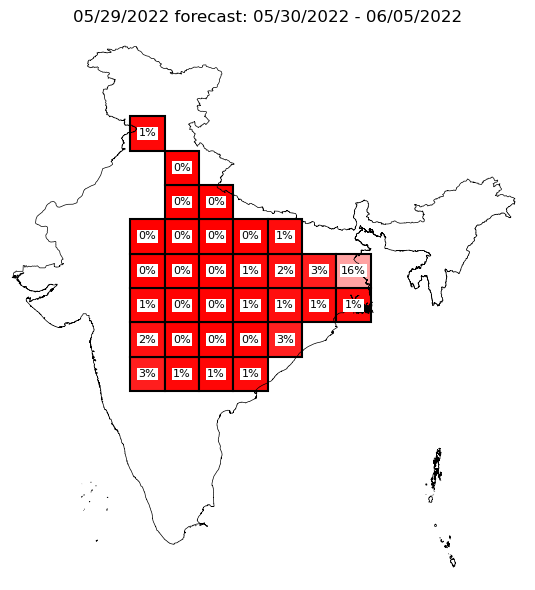

Saving map for Forecast_p_2 on 2022-05-29


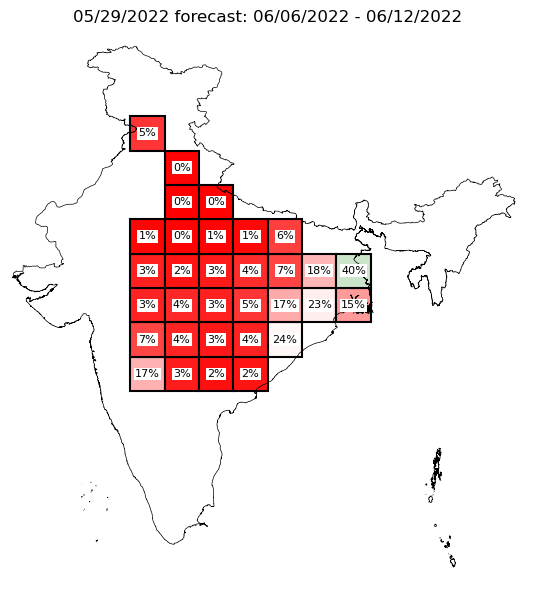

Saving map for Forecast_p_3 on 2022-05-29


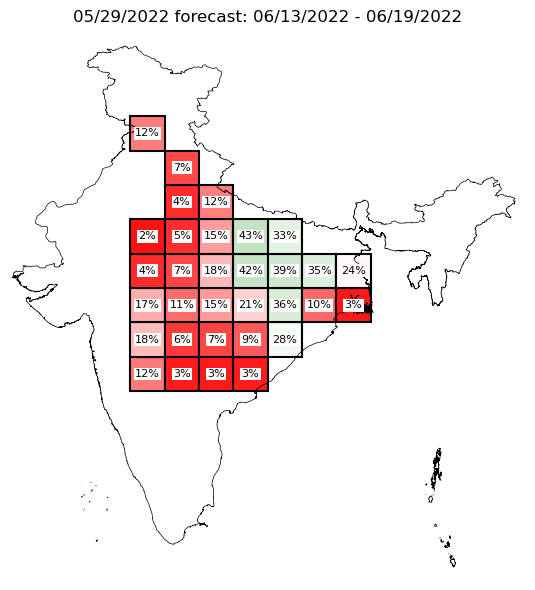

Saving map for Forecast_p_4 on 2022-05-29


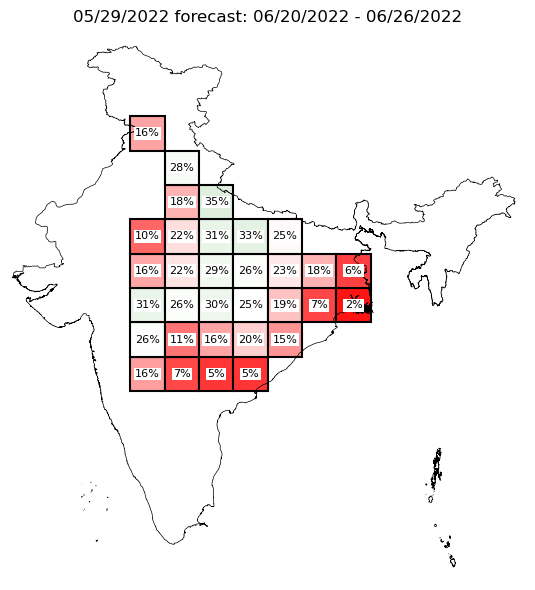

Saving map for Forecast_p_12 on 2022-05-29


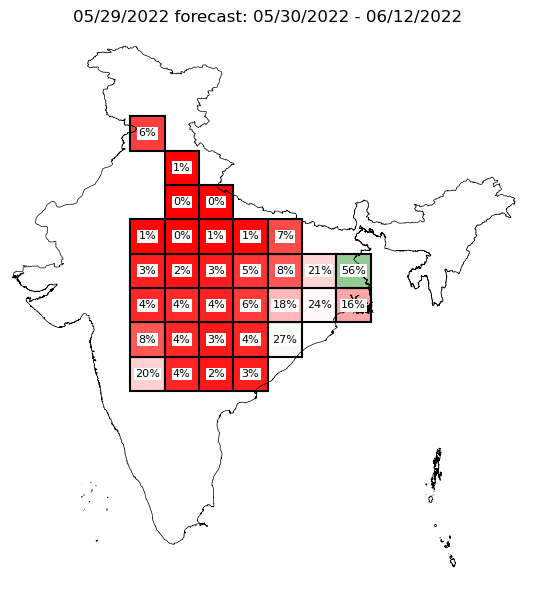

Saving map for Forecast_p_34 on 2022-05-29


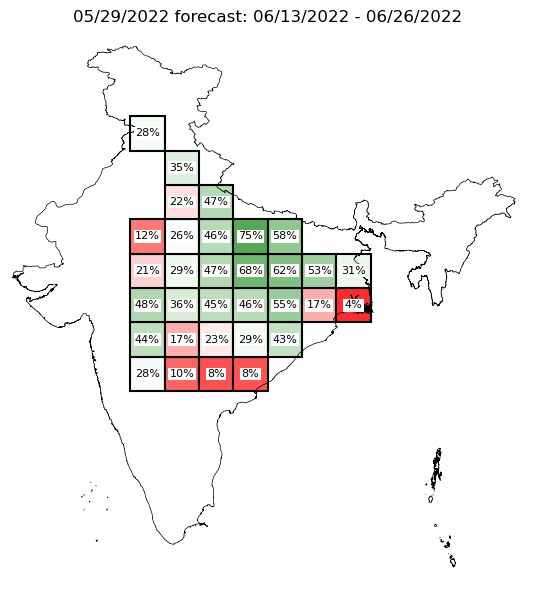

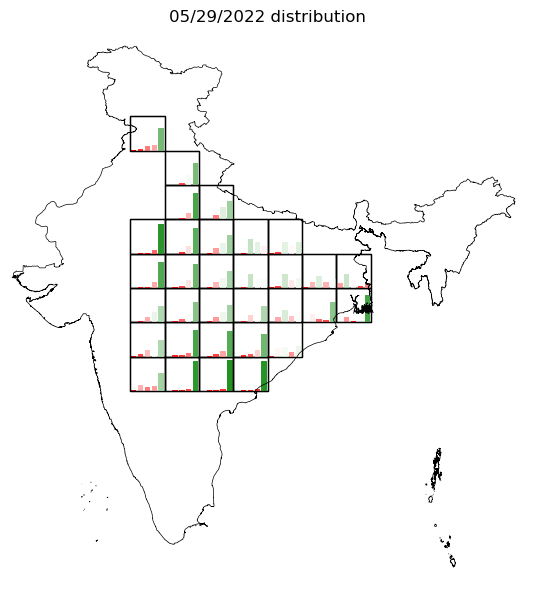

All maps saved under the `maps/` directory


In [121]:
# AI-Generated: PLEASE CHECK BEFORE DEPLOYMENT

from datetime import timedelta
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import geopandas as gpd
from shapely.geometry import Polygon

# india_boundary_csv = "/scratch/midway3/marchakitus/monsoon-onset/blend/utils/india_boundary_for_ggplot.csv"
india_boundary_csv = "/scratch/midway3/marchakitus/monsoon-onset/blend/data/india_shapefile/India_Country_Boundary.shp"

# ------------------------------------------------------------------------------
# 0) Ensure output folder exists
# ------------------------------------------------------------------------------
os.makedirs("maps", exist_ok=True)


# ------------------------------------------------------------------------------
# 1) Load data
# ------------------------------------------------------------------------------
# summary = pd.read_csv("blend_output_summary.csv", parse_dates=["time"])
preds_df = summary.copy()

# ------------------------------------------------------------------------------
# 2) Add climatology & combined‐weeks & outlines
# ------------------------------------------------------------------------------
for i in range(1, 5):
    preds_df[f'Climatology_p_{i}'] = preds_df[f'clim_week{i}']
    preds_df[f'Forecast_p_{i}']     = preds_df[f'week{i}']

preds_df['Climatology_p_12'] = preds_df['Climatology_p_1'] + preds_df['Climatology_p_2']
preds_df['Climatology_p_34'] = preds_df['Climatology_p_3'] + preds_df['Climatology_p_4']
preds_df['Forecast_p_12']    = preds_df['Forecast_p_1']   + preds_df['Forecast_p_2']
preds_df['Forecast_p_34']    = preds_df['Forecast_p_3']   + preds_df['Forecast_p_4']

for tag in ['1','2','3','4','12','34']:
    clim = preds_df[f'Climatology_p_{tag}']
    fcst = preds_df[f'Forecast_p_{tag}']
    preds_df[f'outline_{tag}'] = np.where(
        clim >= fcst + 0.10, 'red',
        np.where(fcst >= clim + 0.10, 'green', 'black')
    )

# ------------------------------------------------------------------------------
# 3) Rectangle corners
# ------------------------------------------------------------------------------
preds_df['lon_min'] = preds_df['lon'] - 1
preds_df['lon_max'] = preds_df['lon'] + 1
preds_df['lat_min'] = preds_df['lat'] - 1
preds_df['lat_max'] = preds_df['lat'] + 1

# ------------------------------------------------------------------------------
# 4) India boundary as GeoDataFrame
# ------------------------------------------------------------------------------
# ib = pd.read_csv(india_boundary_csv)
# polys = []
# for grp, df_grp in ib.groupby('group'):
#     coords = list(zip(df_grp['long'], df_grp['lat']))
#     polys.append(Polygon(coords))
# india_gdf = gpd.GeoDataFrame({'geometry': polys}, crs="EPSG:4326")
india_boundary = gpd.read_file(india_boundary_csv)
india_gdf = india_boundary.to_crs("EPSG:4326")

# ------------------------------------------------------------------------------
# 5) Color map & norm
# ------------------------------------------------------------------------------
cmap = LinearSegmentedColormap.from_list('rwg', ['red','white','green'])
norm = TwoSlopeNorm(vmin=0, vcenter=0.25, vmax=1)

# which probability fields
plots = {
    '1':  'Forecast_p_1',
    '2':  'Forecast_p_2',
    '3':  'Forecast_p_3',
    '4':  'Forecast_p_4',
    '12': 'Forecast_p_12',
    '34': 'Forecast_p_34'
}

# ------------------------------------------------------------------------------
# 6) Scalar‐value maps (weeks 1,2,3,4,12,34)
# ------------------------------------------------------------------------------
for t, grp in preds_df.groupby('time'):
    date_str = t.strftime("%Y-%m-%d")
    date_str = t.strftime("2022-%m-%d")
    date_str_fmt = t.strftime("%m/%d/%Y")
    date_str_fmt = t.strftime("%m/%d/2022")

    for tag, var in plots.items():
        # compute week‐range offsets
        if tag in ['1','2','3','4']:
            start_off = (int(tag)-1)*7 + 1
            end_off   = start_off + 6
        elif tag == '12':
            start_off, end_off = 1, 14
        else:  # '34'
            start_off, end_off = 15, 28

        start_dt = t + timedelta(days=start_off)
        end_dt   = t + timedelta(days=end_off)

        fig, ax = plt.subplots(figsize=(6, 6))
        india_gdf.boundary.plot(ax=ax, linewidth=0.5, edgecolor='black')

        for _, row in grp.iterrows():
            val = row[var]
            if pd.notna(val):
                # colored cell
                rect = Rectangle(
                    (row['lon_min'], row['lat_min']),
                    row['lon_max'] - row['lon_min'],
                    row['lat_max'] - row['lat_min'],
                    facecolor=cmap(norm(val)),
                    edgecolor='black',
                    linewidth=0.5
                )
                ax.add_patch(rect)

                # percentage text with opaque white box
                pct = int(round(val * 100))
                ax.text(
                    row['lon'], row['lat'],
                    f"{pct}%",
                    ha='center', va='center',
                    fontsize=8,
                    bbox=dict(facecolor='white', edgecolor='none', pad=1)
                )

                # colored outline
                ol = Rectangle(
                    (row['lon_min'], row['lat_min']),
                    row['lon_max'] - row['lon_min'],
                    row['lat_max'] - row['lat_min'],
                    fill=False,
                    edgecolor='k',
                    linewidth=1.5
                )
                ax.add_patch(ol)

        ax.set_title(f"{date_str_fmt} forecast: "
                    f"{start_dt.strftime('%m/%d/2022')} - {end_dt.strftime('%m/%d/2022')}")
                    #  f"{start_dt.strftime('%m/%d/%Y')} - {end_dt.strftime('%m/%d/%Y')}")
        ax.set_xlim(68, 98)
        ax.set_ylim(6, 38)
        ax.set_aspect('equal')
        ax.axis('off')
        plt.tight_layout()
        print(f"Saving map for {var} on {date_str}")
        plt.show()
        # plt.savefig(f"maps/map_week{tag}_{date_str}.png", dpi=150)
        plt.close(fig)
# ------------------------------------------------------------------------------
# 7) Bar‐chart maps (week1, week2, week3, week4, later) with cell outlines
# ------------------------------------------------------------------------------
for t, grp in preds_df.groupby('time'):
    date_str = t.strftime("%Y-%m-%d")
    date_str = t.strftime("2022-%m-%d")
    date_str_fmt = t.strftime("%m/%d/%Y")
    date_str_fmt = t.strftime("%m/%d/2022")

    fig, ax = plt.subplots(figsize=(6, 6))
    india_gdf.boundary.plot(ax=ax, linewidth=0.5, edgecolor='black')

    for _, row in grp.iterrows():
        # dimensions of the full cell
        w = row['lon_max'] - row['lon_min']
        h = row['lat_max'] - row['lat_min']
        n_bars = 5
        bar_w = (w / n_bars) * 0.8
        gap   = (w / n_bars) * 0.2

        # draw the little bars
        for i, col in enumerate([
            'Forecast_p_1',
            'Forecast_p_2',
            'Forecast_p_3',
            'Forecast_p_4',
            'later'
        ]):
            val = row[col]
            if pd.notna(val):
                bar_h = h * val
                x0 = row['lon_min'] + i * (w / n_bars) + gap/2
                bar = Rectangle(
                    (x0, row['lat_min']),
                    bar_w, bar_h,
                    facecolor=cmap(norm(val)),
                    edgecolor='none'
                )
                ax.add_patch(bar)

        # outline the full cell
                cell_border = Rectangle(
                    (row['lon_min'], row['lat_min']),
                    w, h,
                    fill=False,
                    edgecolor='black',
                    linewidth=0.8
                )
                ax.add_patch(cell_border)

    ax.set_title(f"{date_str_fmt} distribution")
    ax.set_xlim(68, 98)
    ax.set_ylim(6, 38)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    # plt.savefig(f"maps/map_bars_{date_str}.png", dpi=150)
    # plt.close(fig)
    # ax.set_title(f"{date_str_fmt} distribution")
    # ax.set_xlim(68, 98)
    # ax.set_ylim(6, 36)
    # ax.set_aspect('equal')
    # ax.axis('off')
    # plt.tight_layout()
    # # plt.savefig(f"maps/map_bars_{date_str}.png", dpi=150)
    plt.close(fig)

print("All maps saved under the `maps/` directory")
